# Evaluate the created isochrones against existing data and with results from varioues days

In [1]:
import geopandas as gpd
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# input data
PATH_GRAPHS_IN = "../data/in/osmnx_graphs/"
PATH_STOPS_IN = "../data/out/stop_dfs/"

# output data
PATH_ISOCHRONES_OUT = "../data/out/isochrones_gpkg/"
PATH_FIGS_OUT = "../data/out/figs/"


PTSQL_COLORS = {"A":"#E42421", "B":"#E95153", "C":"#E63C1E", "D":"#F29668", "E":"#34672B", "F":"#87C281", "G":"#959595", "H":"none"}

file = "all_regions_20241023.gpkg"
days = [20240210, 20240410, 20240610, 20240810, 20241010, 20241210, 20241023, 20241030]

In [3]:
# load gpkg
def load_isochrones(file):
    """
    Load isochrones from gpkg file and preprocess for area calculation

    Parameters
        file (str): name of file in out/isochrones_gpkg/ folder
    Returns
        isochrones (gpd.GeoDataFrame): isochrones with additional column "ptsql"
    """
    isochrones = gpd.read_file(f"{PATH_ISOCHRONES_OUT}{file}")
    isochrones = isochrones.iloc[1:]
    isochrones['ptsql'] = isochrones['color'].apply(lambda x: [key for key, value in PTSQL_COLORS.items() if value == x][0])
    isochrones = isochrones.reset_index().drop(columns=['index'])
    isochrones = isochrones.sort_values("ptsql", ascending=False)
    return isochrones

def calculate_areas(isochrones):
    """
    Calcaulate area of each ptsql category. Starts by last category (G) and subtracts areas of all previous categories.

    Parameters
        isochrones (gpd.GeoDataFrame): isochrones with additional column "ptsql"
    Returns
        areas (dict): dictionary of ptsql category and area
    """
    areas = {}
    for i in range(len(isochrones)):
        a = isochrones.iloc[[i]].dissolve().geometry.iloc[0]
        
        if i == len(isochrones)-1:
            areas[isochrones.iloc[i].ptsql] = a.area / 1000000
            break

        b = isochrones.iloc[i+1:].dissolve().geometry.iloc[0]
        areas[isochrones.iloc[i].ptsql] = a.difference(b).area / 1000000

    return dict(reversed(areas.items()))

def create_area_df(days):
    """
    Create dataframe of areas for each ptsql category for each day

    Parameters
        days (list): list of days to read gpkg and calculate areas for
    Returns
        df (pd.DataFrame): dataframe of areas for each ptsql category for each day
    """
    area_dicts = []
    for day in days:
        f = f"all_regions_{day}.gpkg"
        iso = load_isochrones(f)
        area_dicts.append(calculate_areas(iso))
    
    df = pd.DataFrame(area_dicts)
    #df = df.astype(float)
    df.insert(0, "date", days)
    
    return df

isochrones = load_isochrones(file)
display(isochrones)

calculate_areas(isochrones)

,color,center,distance,geometry,ptsql
0,#959595,POINT (628765.9687516089 421200.4922992469),1250.0,"MULTIPOLYGON (((123494.636 371016.499, 123494....",G
1,#87C281,POINT (628765.9687516089 421200.4922992469),1000.0,"MULTIPOLYGON (((121933.014 372095.991, 121932....",F
2,#34672B,POINT (628765.9687516089 421200.4922992469),750.0,"MULTIPOLYGON (((121174.865 374101.714, 121174....",E
3,#F29668,POINT (628765.9687516089 421200.4922992469),500.0,"MULTIPOLYGON (((119501.342 374982.474, 119501....",D
4,#E63C1E,POINT (628765.9687516089 421200.4922992469),300.0,"MULTIPOLYGON (((125270.232 371374.828, 125270....",C
5,#E95153,POINT (629679.5605139488 430974.5841346277),300.0,"MULTIPOLYGON (((130603.019 370597.819, 130602....",B
6,#E42421,POINT (617798.7349675348 380474.6811468543),300.0,"MULTIPOLYGON (((140628.133 358995.916, 140628....",A


{'A': 209.14374892763016,
 'B': 242.60915273775854,
 'C': 433.827640623255,
 'D': 795.0295798093845,
 'E': 1221.2346473396333,
 'F': 1980.3994893504546,
 'G': 5582.165922978418}

In [4]:
df = create_area_df(days)
df

,date,A,B,C,D,E,F,G
0,20240210,121.841746,150.388045,277.810097,530.713675,763.766984,1183.800438,3423.115057
1,20240410,202.666708,240.764709,463.497879,871.563153,1344.699616,2145.414570,5839.640612
2,20240610,201.307325,238.269649,457.856654,870.938477,1348.440087,2156.627682,5875.329073
3,20240810,123.680961,157.894605,276.274533,519.547516,752.129579,1193.817432,3528.393922
4,20241010,232.067950,261.455228,476.428777,871.012787,1335.920850,2145.116151,5892.101714
5,20241210,239.209587,266.565236,488.223914,885.243327,1355.013459,2185.490174,6023.458489
6,20241023,209.143749,242.609153,433.827641,795.029580,1221.234647,1980.399489,5582.165923
7,20241030,186.754479,219.843595,389.768369,696.941228,1025.708252,1642.388599,4712.525366


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    8 non-null      int64  
 1   A       8 non-null      float64
 2   B       8 non-null      float64
 3   C       8 non-null      float64
 4   D       8 non-null      float64
 5   E       8 non-null      float64
 6   F       8 non-null      float64
 7   G       8 non-null      float64
dtypes: float64(7), int64(1)
memory usage: 644.0 bytes


In [25]:
def create_evaluation_plot(df, day1, day2, matrix=False, note_text=False, percent=False):
    """
    Create a heatmap of the differences between the two days.

    Parameters:
        df (pd.DataFrame): The DataFrame containing the area sizes for each ptsql category as columns and the days as rows. Cols: "date, A, B, C, D, E, F, G".
        day1 (int): The first day for which the areas should be compared. Must match an entry in the "date" column in the DataFrame.
        day2 (int): The second day for which the areas should be compared. Must match an entry in the "date" column in the DataFrame.
        matrix (bool, optional): Whether to return a matrix of differences (squared heatmap) instead of a one-dimensional heatmap. Defaults to False.
        note_text (bool, optional): Whether to add a note to the plot indicating the direction of the differences. Defaults to False.
        percent (bool, optional): Whether to display the differences as percentages instead of absolute values. Defaults to False.
    """
    # TODO: add percentages to matrix plot
    d1 = pd.to_datetime(str(day1))
    d2 = pd.to_datetime(str(day2))

    row_day1 = df[df["date"] == day1].drop(columns=["date"])
    row_day2 = df[df["date"] == day2].drop(columns=["date"])
    labels = row_day1.columns.tolist()

    if matrix:
        pair_wise_diff = np.subtract.outer(row_day1.values.flatten(), row_day2.values.flatten())
        
        plot = sns.heatmap(pair_wise_diff, annot=True, xticklabels=labels, yticklabels=labels, cmap="coolwarm", center=0)
        plt.xlabel(f"PTSQL {day2.date()}")
        plt.ylabel(f"PTSQL {day1.date()}")
    else:
        if percent:
            diff = row_day1.values / row_day2.values * 100
        else:
            diff = row_day1.values - row_day2.values

        plot = sns.heatmap(diff, annot=True, xticklabels=labels, yticklabels=["Difference"], cmap="coolwarm", fmt=".1f")

        plt.xlabel("PTSQL")

    plt.title(f"Difference between {d1.date()} and {d2.date()}")
    if note_text:
        plt.figtext(x=0.5, y=-0.02, s=f"Positive values indicate a larger in area for {d1.date()}. Close to zero is best.", ha="center", fontsize=10)

    return plot

<Axes: title={'center': 'Difference between 2024-10-23 and 2024-10-30'}, xlabel='PTSQL'>

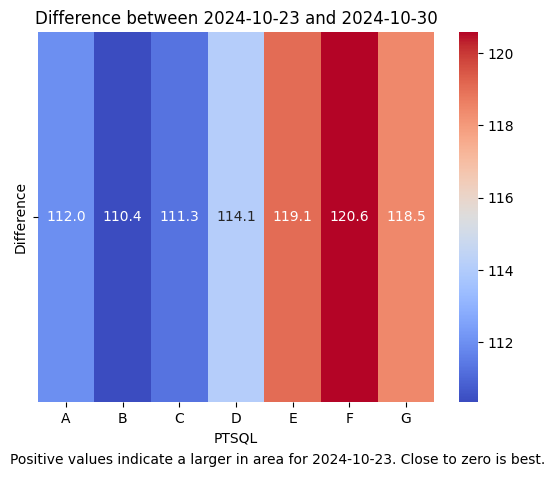

In [26]:
create_evaluation_plot(df, 20241023, 20241030, matrix=False, percent=True, note_text=True)

In [12]:
def create_time_series_plot(df, days=[]):
    if len(days) == 0:
        days = list(df.date.values)
    plot = df[df.date.isin(days)].plot(kind='bar', x='date', stacked=True, color=PTSQL_COLORS)
    plt.ylabel('Area [km²]')
    plt.legend(loc="center left", bbox_to_anchor=(1,0.8))
    plt.xticks(rotation=45)
    plt.title('Time Series Barplot')

    return plot

<Axes: title={'center': 'Time Series Barplot'}, xlabel='date', ylabel='Area [km²]'>

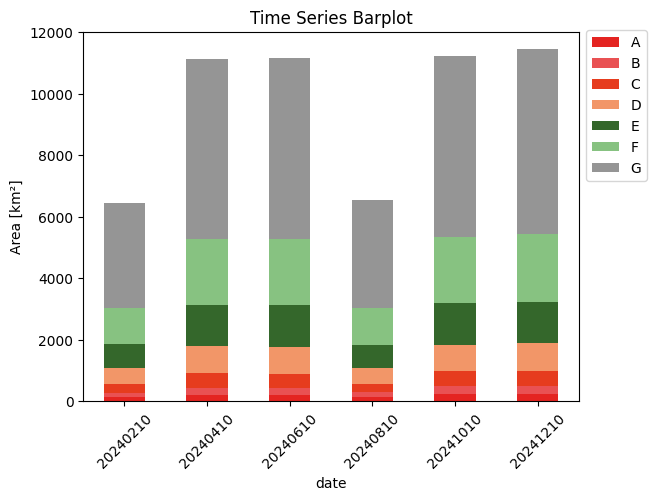

In [13]:
create_time_series_plot(df, days=[20240010+x for x in range(200,1300, 200)])